In [1]:
#1
import pandas as pd
import numpy as np
df = pd.read_csv('data(lab6).csv')
print(f"Форма DataFrame: {df.shape}")
print("\n============================")
print("Типы данных:")
print(df.dtypes)
print("\n============================")
print("Пропуски:")
print(df.isnull().sum())
print("\n============================")
print("Первые 5 строк:")
print(df.head())

Форма DataFrame: (10000, 50)

Типы данных:
col_1     object
col_2      int64
col_3      int64
col_4     object
col_5      int64
col_6      int64
col_7     object
col_8      int64
col_9      int64
col_10    object
col_11     int64
col_12     int64
col_13    object
col_14     int64
col_15     int64
col_16    object
col_17     int64
col_18     int64
col_19    object
col_20     int64
col_21     int64
col_22    object
col_23     int64
col_24     int64
col_25    object
col_26     int64
col_27     int64
col_28    object
col_29     int64
col_30     int64
col_31    object
col_32     int64
col_33     int64
col_34    object
col_35     int64
col_36     int64
col_37    object
col_38     int64
col_39     int64
col_40    object
col_41     int64
col_42     int64
col_43    object
col_44     int64
col_45     int64
col_46    object
col_47     int64
col_48     int64
col_49    object
col_50     int64
dtype: object

Пропуски:
col_1     0
col_2     0
col_3     0
col_4     0
col_5     0
col_6     0
col_7     

In [5]:
#2
for col in df.columns:
    converted = pd.to_numeric(df[col], errors='coerce')
    if converted.notna().any():
        df[col] = converted
        mean_val = df[col].mean()
        df[col] = df[col].fillna(mean_val)
print(df.head())

    col_1  col_2  col_3        col_4  col_5  col_6     col_7  col_8  col_9  \
0    Home    762    303  Electronics     49    348  Clothing    206    123   
1  Sports    190     34       Sports    107     99  Clothing    836    775   
2   Books    711      2         Home     93    876      Home    868     69   
3  Sports    484    362        Books    636    361      Home    897    111   
4  Sports    733    195         Home    829    937  Clothing    428    871   

        col_10  ...  col_41  col_42    col_43  col_44  col_45       col_46  \
0       Sports  ...     676     471      Home     511     424  Electronics   
1  Electronics  ...     700     696     Books     329     677  Electronics   
2        Books  ...     418     596      Home     781     622  Electronics   
3     Clothing  ...     620     357      Home     811     240     Clothing   
4         Home  ...     740     845  Clothing     272     143  Electronics   

   col_47  col_48       col_49  col_50  
0     511     484    

In [6]:
#3
df['total_value'] = df['col_2'] * df['col_3']
df['double_stock'] = df['col_3'] * 2
df['log_price'] = np.log(df['col_2'])
w = ['col_1', 'col_2', 'col_3', 'total_value', 'double_stock', 'log_price']
print(df[w].head())

    col_1  col_2  col_3  total_value  double_stock  log_price
0    Home    762    303       230886           606   6.635947
1  Sports    190     34         6460            68   5.247024
2   Books    711      2         1422             4   6.566672
3  Sports    484    362       175208           724   6.182085
4  Sports    733    195       142935           390   6.597146


In [7]:
#4
q = df[(df['col_2'] > 500) & (df['col_7'] == 'Electronics')]
print(q.head())

          col_1  col_2  col_3        col_4  col_5  col_6        col_7  col_8  \
10         Home    605    250         Home    927    617  Electronics    506   
16         Home    670    334  Electronics    548    396  Electronics    994   
63     Clothing    926     35         Home    138    312  Electronics    197   
66     Clothing    716    813        Books    794    346  Electronics    448   
70  Electronics    937    526     Clothing    987    507  Electronics    421   

    col_9    col_10  ...  col_44  col_45       col_46  col_47  col_48  \
10    793  Clothing  ...     397     950       Sports     354     991   
16    942     Books  ...     277     250  Electronics     374     801   
63    966      Home  ...      30     956     Clothing     658     141   
66    870      Home  ...     756     593       Sports     840     627   
70    905     Books  ...     104      38     Clothing     499     265   

      col_49  col_50  total_value double_stock  log_price  
10     Books     314

In [8]:
#5
summary_table = df.groupby('col_7').agg({'col_2': ['mean', 'max'], 'col_3': 'sum'}).reset_index()
summary_table.columns = ['category', 'mean_price', 'max_price', 'total_quantity']
print(summary_table)

      category  mean_price  max_price  total_quantity
0        Books  494.009027        999          982076
1     Clothing  495.738608        999         1008454
2  Electronics  505.886228        999         1009669
3         Home  511.097561        999          995489
4       Sports  509.046637        999         1008988


In [9]:
#6
target_cols = [f'col_{i}' for i in range(2, 12)]
subset = df[target_cols]
stats_df = subset.select_dtypes(include=[np.number]).agg(['mean', 'median', 'std']).T
stats_df = stats_df.reset_index()
stats_df.columns = ['column', 'mean', 'median', 'std']
print(stats_df)

   column      mean  median         std
0   col_2  503.1608   509.0  289.808030
1   col_3  500.4676   502.5  288.052132
2   col_5  494.9370   493.0  290.634660
3   col_6  500.0842   502.0  287.772049
4   col_8  500.1320   498.0  287.280092
5   col_9  494.8945   488.0  288.756643
6  col_11  499.8112   501.0  287.426535


In [10]:
#7
threshold = df['col_2'].mean() + df['col_2'].std()
anomalies = df[df['col_2'] > threshold]
print(anomalies.head())

    col_1  col_2  col_3        col_4  col_5  col_6     col_7  col_8  col_9  \
8   Books    836    647  Electronics     11    519     Books    149    924   
11  Books    812    147     Clothing    395    921      Home    168    322   
14   Home    989    254        Books    361    736     Books     13    674   
22   Home    987    562         Home    997    867    Sports    616    765   
25  Books    949    822       Sports    396    170  Clothing    660    303   

    col_10  ...  col_44  col_45  col_46  col_47  col_48       col_49  col_50  \
8   Sports  ...     572     706  Sports     976     179         Home     341   
11  Sports  ...      47     310    Home     509     110     Clothing     316   
14  Sports  ...     212     706   Books     764     970         Home       1   
22   Books  ...     698     759    Home     431     535  Electronics     237   
25  Sports  ...     937     363  Sports     212     668  Electronics      11   

    total_value double_stock  log_price  
8       

In [11]:
#8
target_cols = [f'col_{i}' for i in range(2, 12)]
corr_matrix = df[target_cols].corr(numeric_only=True)
print(corr_matrix.round(2))

        col_2  col_3  col_5  col_6  col_8  col_9  col_11
col_2    1.00  -0.01  -0.00  -0.00   0.02  -0.01   -0.01
col_3   -0.01   1.00   0.02   0.00   0.01   0.00    0.00
col_5   -0.00   0.02   1.00   0.02   0.02   0.01   -0.00
col_6   -0.00   0.00   0.02   1.00  -0.01   0.00   -0.02
col_8    0.02   0.01   0.02  -0.01   1.00  -0.01    0.00
col_9   -0.01   0.00   0.01   0.00  -0.01   1.00    0.02
col_11  -0.01   0.00  -0.00  -0.02   0.00   0.02    1.00


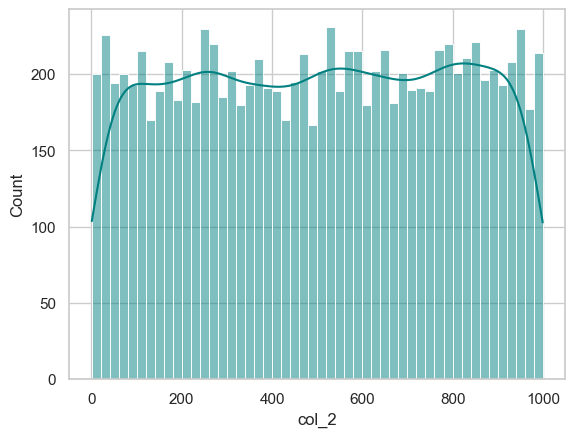

In [2]:
#9
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style="whitegrid")
sns.histplot(df['col_2'], bins=50, kde=True, color="teal")
plt.show()

/Users/onlocc3r/PyCharmMiscProject/.venv/lib/python3.9/site-packages/numpy/linalg/_linalg.py:3220: RuntimeWarning: divide by zero encountered in matmul
  return _core_matmul(x1, x2)
/Users/onlocc3r/PyCharmMiscProject/.venv/lib/python3.9/site-packages/numpy/linalg/_linalg.py:3220: RuntimeWarning: overflow encountered in matmul
  return _core_matmul(x1, x2)
/Users/onlocc3r/PyCharmMiscProject/.venv/lib/python3.9/site-packages/numpy/linalg/_linalg.py:3220: RuntimeWarning: invalid value encountered in matmul
  return _core_matmul(x1, x2)


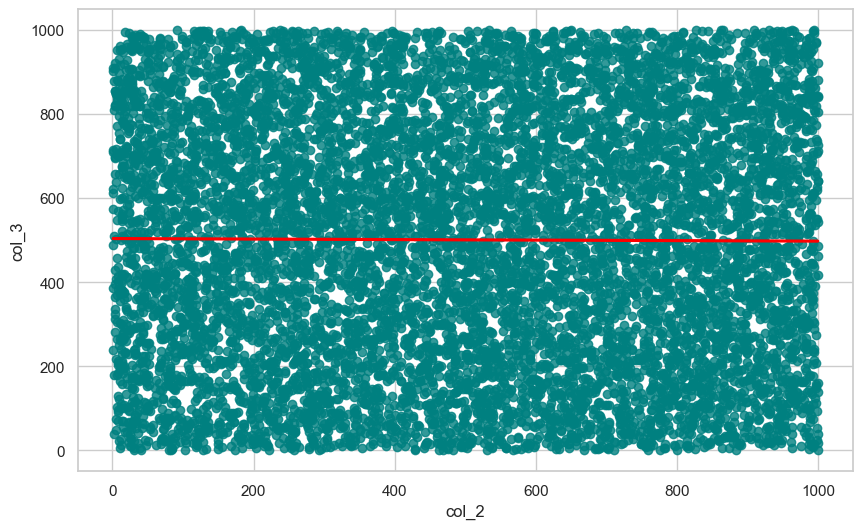

In [19]:
#10
plt.figure(figsize=(10, 6))
sns.regplot(data=df, x='col_2', y='col_3', ci=None, color='teal', line_kws={'color': 'red'})
plt.show()

<Figure size 1200x700 with 0 Axes>

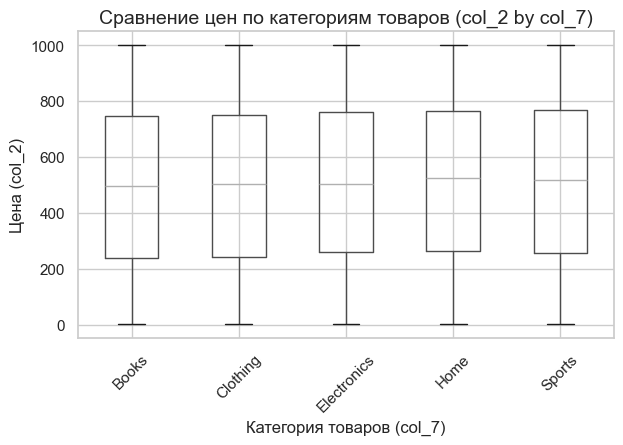

In [20]:
#11
plt.figure(figsize=(12, 7))
df.boxplot(column='col_2', by='col_7', grid=True, rot=45)
plt.title('Сравнение цен по категориям товаров (col_2 by col_7)', fontsize=14)
plt.suptitle('')
plt.xlabel('Категория товаров (col_7)', fontsize=12)
plt.ylabel('Цена (col_2)', fontsize=12)
plt.tight_layout()
plt.show()

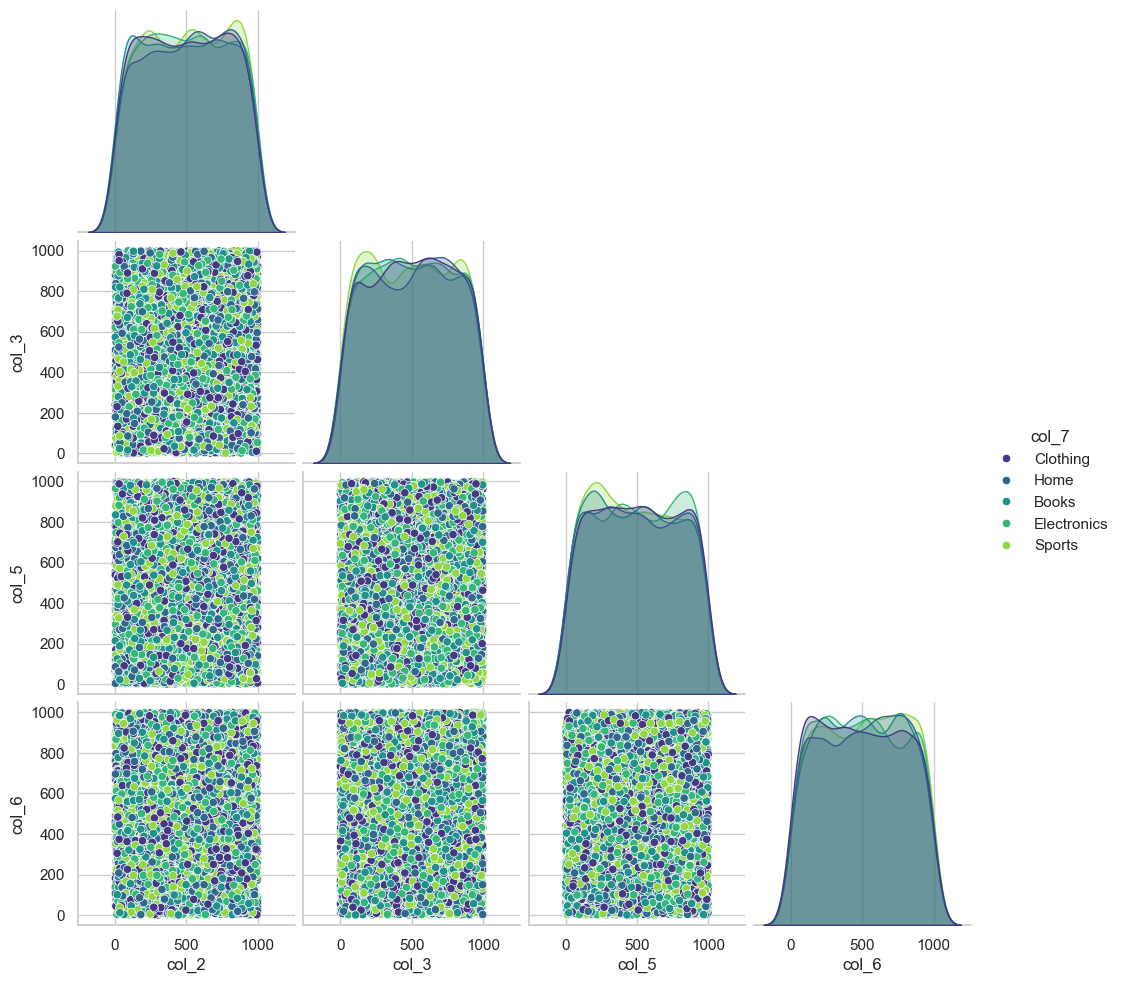

In [21]:
#12
target_cols = [f'col_{i}' for i in range(2, 7)] + ['col_7']
df_subset = df[target_cols]
g = sns.pairplot(df_subset, hue='col_7', palette='viridis', corner=True)
plt.show()

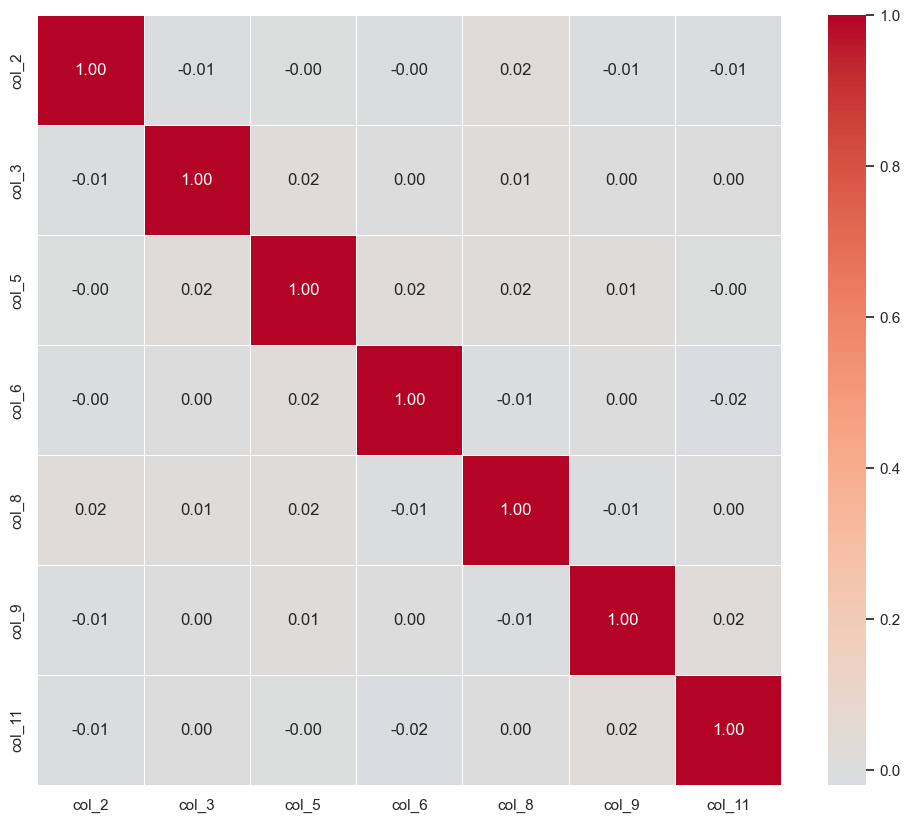

In [22]:
#13
target_cols = [f'col_{i}' for i in range(2, 12)]
numeric_df = df[target_cols].select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', center=0, linewidths=0.5)
plt.show()

In [23]:
#14
original_cols = [f'col_{i}' for i in range(1, 51)]
new_metrics = ['total_value', 'double_stock', 'log_price']
final_columns = [col for col in original_cols + new_metrics if col in df.columns]
df[final_columns].to_csv('catalog_analysis.csv', index=False, sep=';', encoding='utf-8-sig')

In [24]:
#15
df['log_price'] = df['log_price'].replace([float('inf'), float('-inf')], pd.NA)
category_summary = df.groupby('col_7').agg({'col_7': 'count', 'col_2': 'mean', 'col_3': 'sum', 'log_price': 'mean'})
category_summary.columns = ['product_count', 'average_price', 'total_stock', 'avg_log_price']
print(category_summary.head())

             product_count  average_price  total_stock  avg_log_price
col_7                                                                
Books                 1994     494.009027       982076       5.879360
Clothing              1997     495.738608      1008454       5.892562
Electronics           2004     505.886228      1009669       5.933533
Home                  1968     511.097561       995489       5.935257
Sports                2037     509.046637      1008988       5.939490


In [25]:
#16
df_sorted = df.sort_values(by=['col_7', 'col_2'], ascending=True)
most_expensive = df_sorted.groupby('col_7').tail(1)
most_expensive = most_expensive[['col_1', 'col_2', 'col_7']]
print(most_expensive.sort_values(by='col_2', ascending=False))

            col_1  col_2        col_7
4318        Books    999        Books
9117         Home    999     Clothing
7576  Electronics    999  Electronics
8918  Electronics    999         Home
3230     Clothing    999       Sports


In [26]:
#17
df['total_value'] = df['col_2'] * df['col_3']
top_10_inventory = df.sort_values(by='total_value', ascending=False).head(10)
print(top_10_inventory[['col_1', 'col_2', 'col_3', 'total_value']])

            col_1  col_2  col_3  total_value
3833        Books    994    999       993006
4494       Sports    993    997       990021
9335     Clothing    994    992       986048
6431         Home    988    981       969228
3725  Electronics    997    971       968087
3389  Electronics    986    979       965294
3026  Electronics    997    968       965096
9202       Sports    966    996       962136
1380  Electronics    963    998       961074
3956     Clothing    982    975       957450


/var/folders/_4/564fbw5d151bmrmhvhqg73hm0000gn/T/ipykernel_1281/2597288472.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=price_dist, x='price_range', y='count', palette='magma')


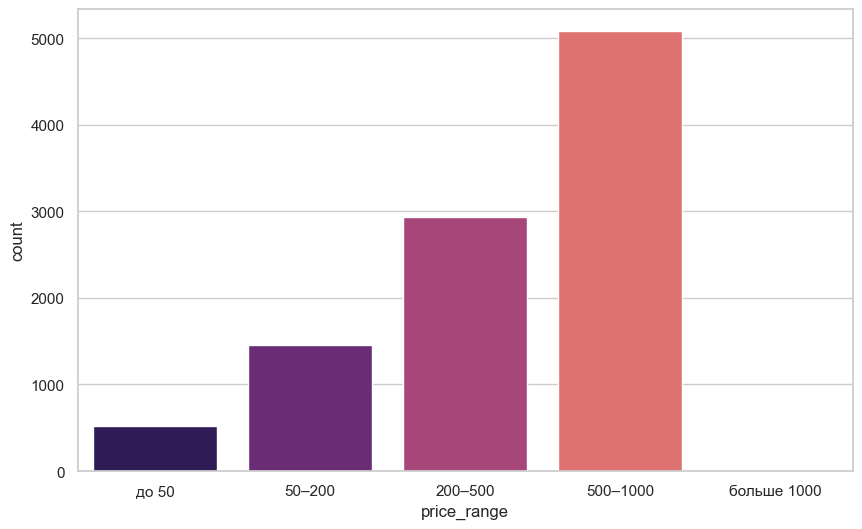

In [27]:
#18
bins = [0, 50, 200, 500, 1000, float('inf')]
labels = ['до 50', '50–200', '200–500', '500–1000', 'больше 1000']
df['price_range'] = pd.cut(df['col_2'], bins=bins, labels=labels, include_lowest=True)
price_dist = df['price_range'].value_counts().reindex(labels).reset_index()
price_dist.columns = ['price_range', 'count']
plt.figure(figsize=(10, 6))
sns.barplot(data=price_dist, x='price_range', y='count', palette='magma')
plt.show()

Категория с наибольшим капиталом: Sports
Суммарная стоимость: 511,957,866.00


/var/folders/_4/564fbw5d151bmrmhvhqg73hm0000gn/T/ipykernel_1485/2981722035.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=category_capital, x='col_7', y='inventory_value', palette='viridis')


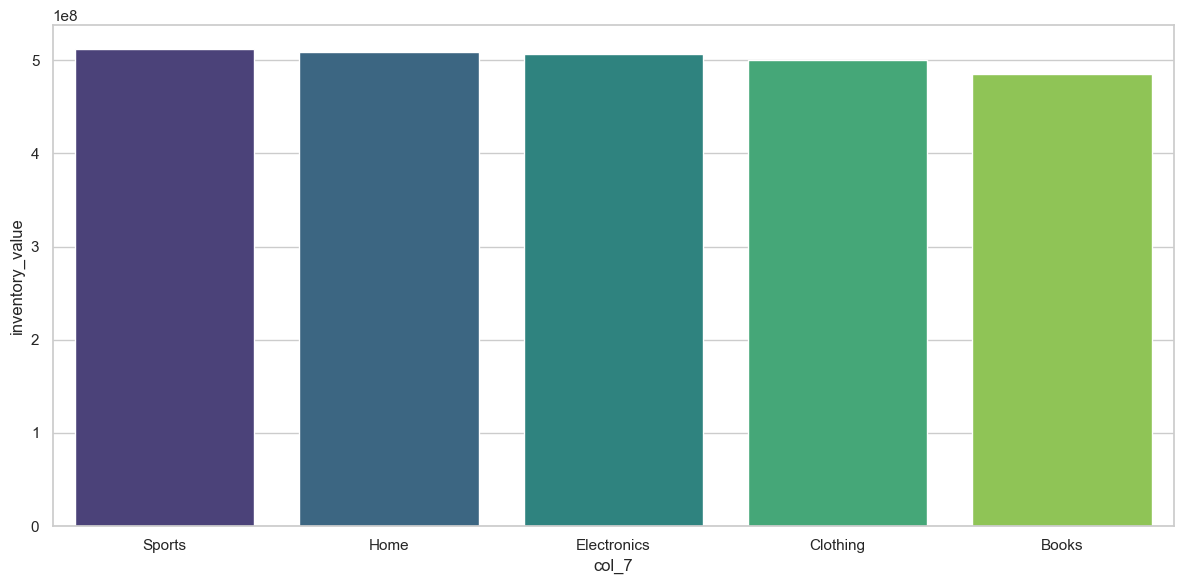

In [35]:
#19
df['inventory_value'] = df['col_2'] * df['col_3']
category_capital = df.groupby('col_7')['inventory_value'].sum().reset_index()
category_capital = category_capital.sort_values(by='inventory_value', ascending=False)
top_category = category_capital.iloc[0]
print(f"Категория с наибольшим капиталом: {top_category['col_7']}")
print(f"Суммарная стоимость: {top_category['inventory_value']:,.2f}")
plt.figure(figsize=(12, 6))
sns.barplot(data=category_capital, x='col_7', y='inventory_value', palette='viridis')
plt.tight_layout()
plt.show()

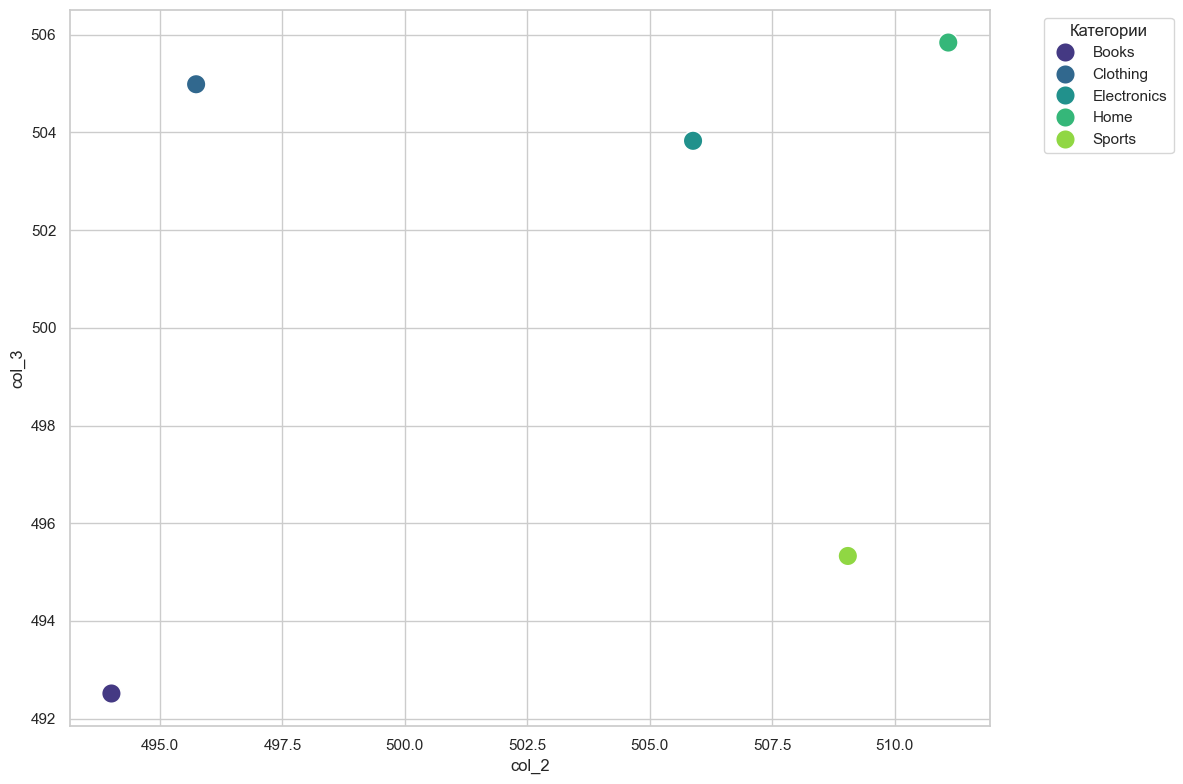

In [31]:
#20
category_stats = df.groupby('col_7').agg({'col_2': 'mean', 'col_3': 'mean'}).reset_index()
plt.figure(figsize=(12, 8))
scatter = sns.scatterplot(data=category_stats, x='col_2', y='col_3', hue='col_7', s=200, palette='viridis')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Категории')
plt.tight_layout()
plt.show()

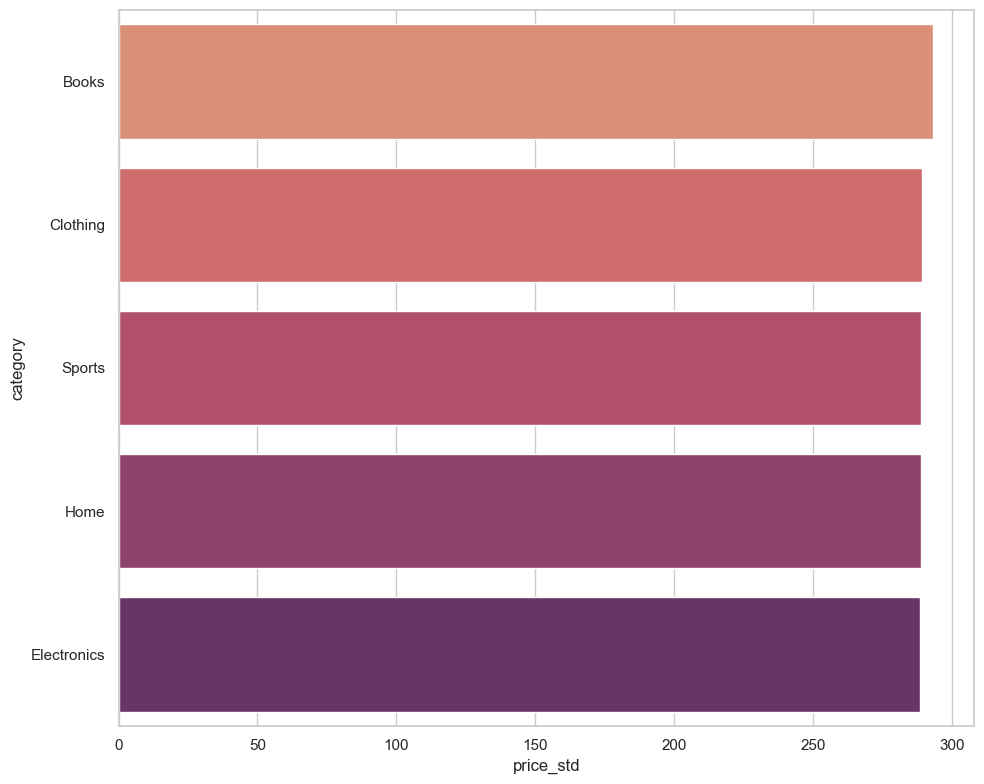

In [33]:
#21
price_spread = df.groupby('col_7')['col_2'].std().reset_index()
price_spread.columns = ['category', 'price_std']
price_spread = price_spread.sort_values(by='price_std', ascending=False)
plt.figure(figsize=(10, 8))
sns.barplot(data=price_spread, x='price_std', y='category', hue='category', palette='flare', legend=False)
plt.tight_layout()
plt.show()

In [15]:
#22
z = df[df['col_3'] == 0][['col_1', 'col_7', 'col_2']]
print(z.head(10))

Empty DataFrame
Columns: [col_1, col_7, col_2]
Index: []


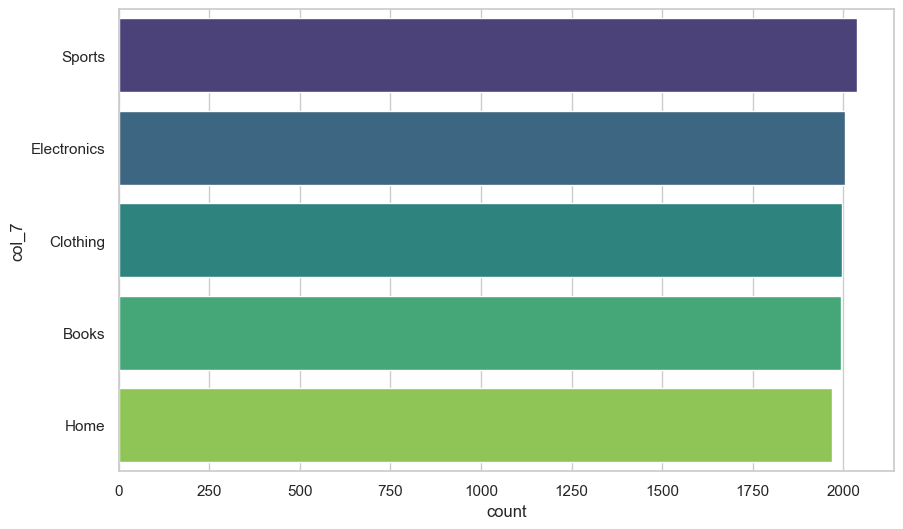

In [30]:
#23
counts = df.groupby('col_7').size().reset_index(name='count')
top_5 = counts.sort_values(by='count', ascending=False).head(5)
plt.figure(figsize=(10, 6))
sns.barplot(data=top_5, x='count', y='col_7', hue='col_7', palette='viridis', legend=False)
plt.show()

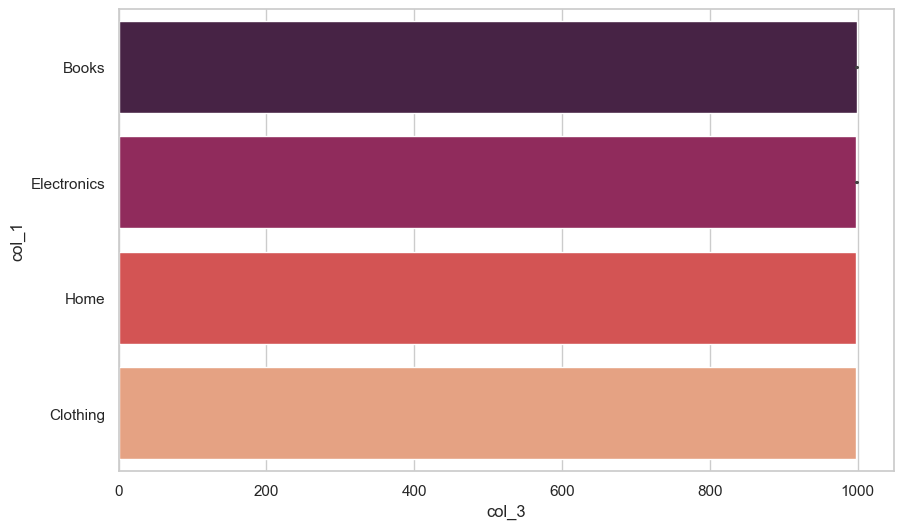

In [37]:
#24
df_sorted = df.sort_values(by='col_3', ascending=False).head(10)
plt.figure(figsize=(10, 6))
sns.barplot(data=df_sorted, x='col_3', y='col_1', hue='col_1', palette='rocket', legend=False)
plt.show()

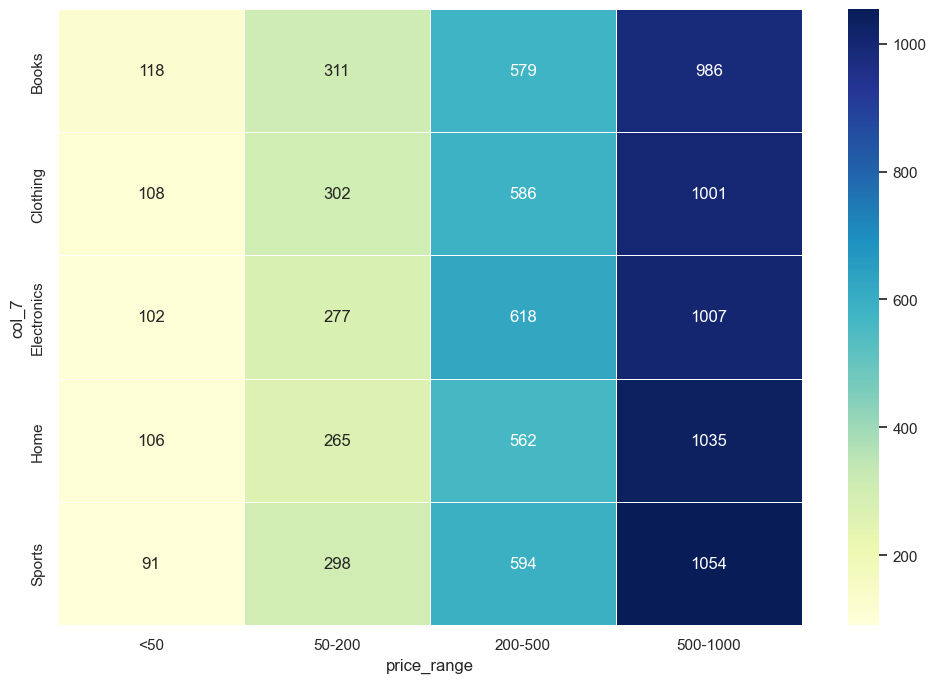

In [38]:
#25
bins = [0, 50, 200, 500, 1000, float('inf')]
labels = ['<50', '50-200', '200-500', '500-1000', '>1000']
df['price_range'] = pd.cut(df['col_2'], bins=bins, labels=labels, include_lowest=True)
heatmap_data = pd.crosstab(df['col_7'], df['price_range'])
plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, annot=True, fmt='d', cmap='YlGnBu', linewidths=.5)
plt.show()

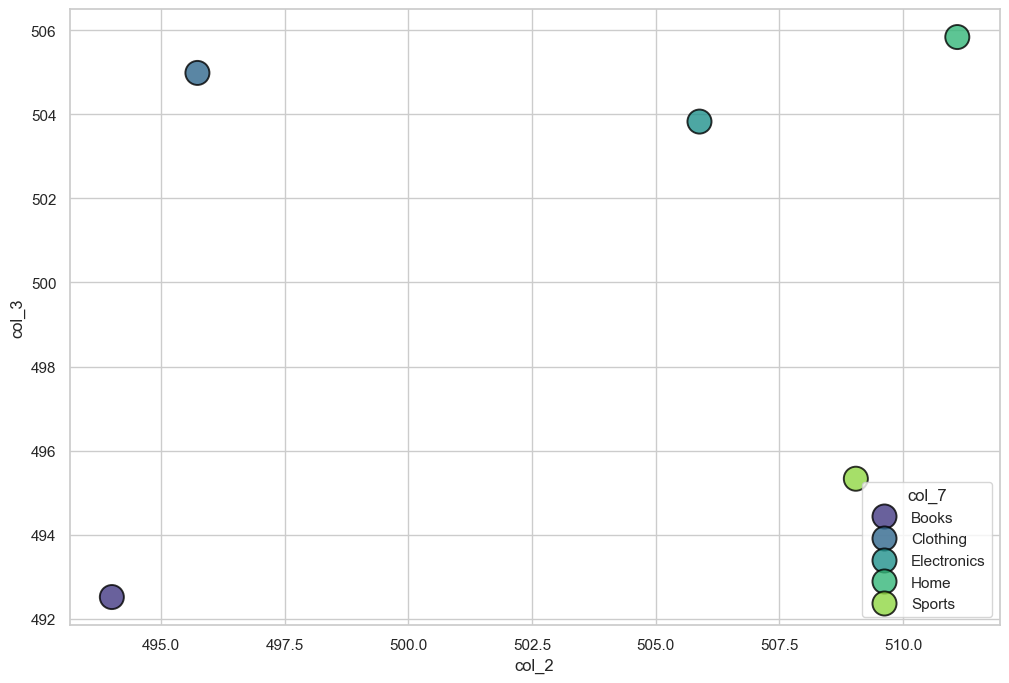

In [3]:
#36
category_analysis = df.groupby('col_7').agg({'col_2': 'mean', 'col_3': 'mean'}).reset_index()
plt.figure(figsize=(12, 8))
scatter = sns.scatterplot(data=category_analysis, x='col_2', y='col_3', hue='col_7', s=300, palette='viridis', edgecolor='black', alpha=0.8)
plt.show()

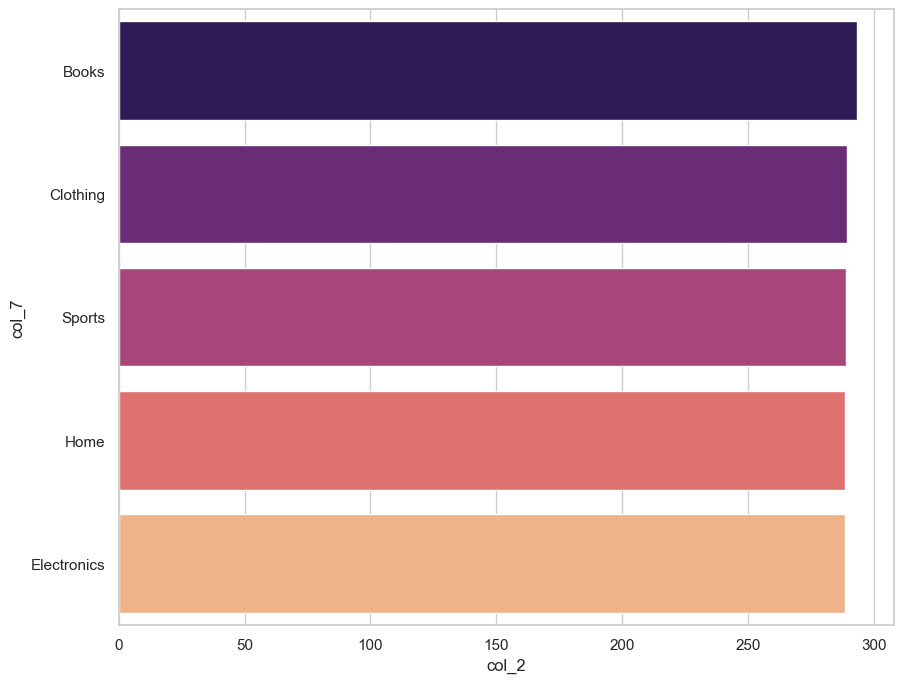

In [6]:
#37
m = df.groupby('col_7')['col_2'].std().reset_index()
m = m.sort_values(by='col_2', ascending=False)
plt.figure(figsize=(10, 8))
sns.barplot(data=m, x='col_2', y='col_7', hue='col_7', palette='magma')
plt.show()

In [7]:
#38
n = df[df['col_3'] == 0]
b = n[['col_1', 'col_7', 'col_2']].head(10)
print(b)

Empty DataFrame
Columns: [col_1, col_7, col_2]
Index: []


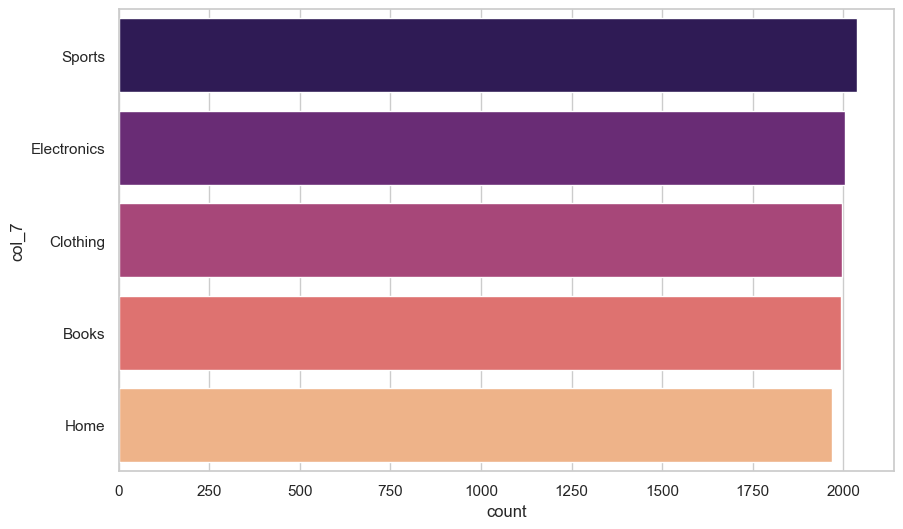

In [11]:
#39
v = df['col_7'].value_counts().head(5).reset_index()
plt.figure(figsize=(10, 6))
sns.barplot(data=v, x='count', y='col_7', hue='col_7', palette='magma')
plt.show()

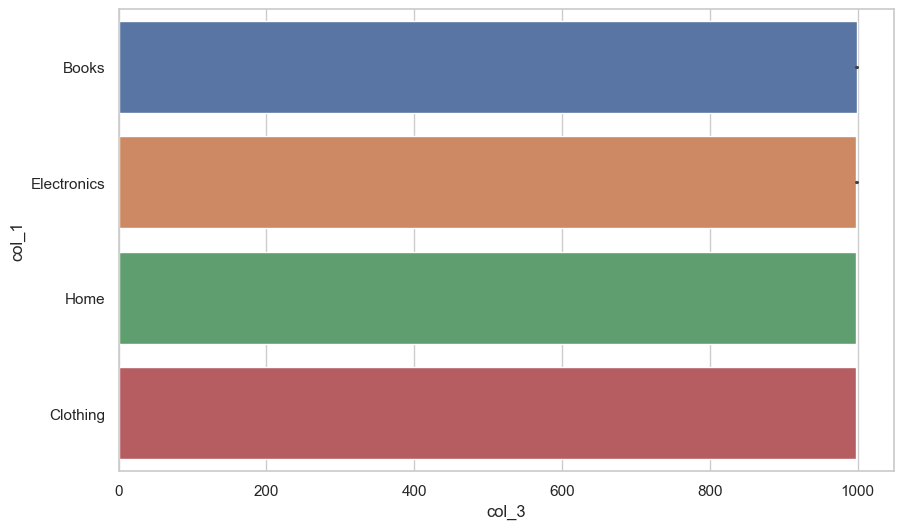

In [16]:
#40
c = df.sort_values(by='col_3', ascending=False).head(10)
plt.figure(figsize=(10, 6))
sns.barplot(data=c, x='col_3', y='col_1', hue='col_1')
plt.show()

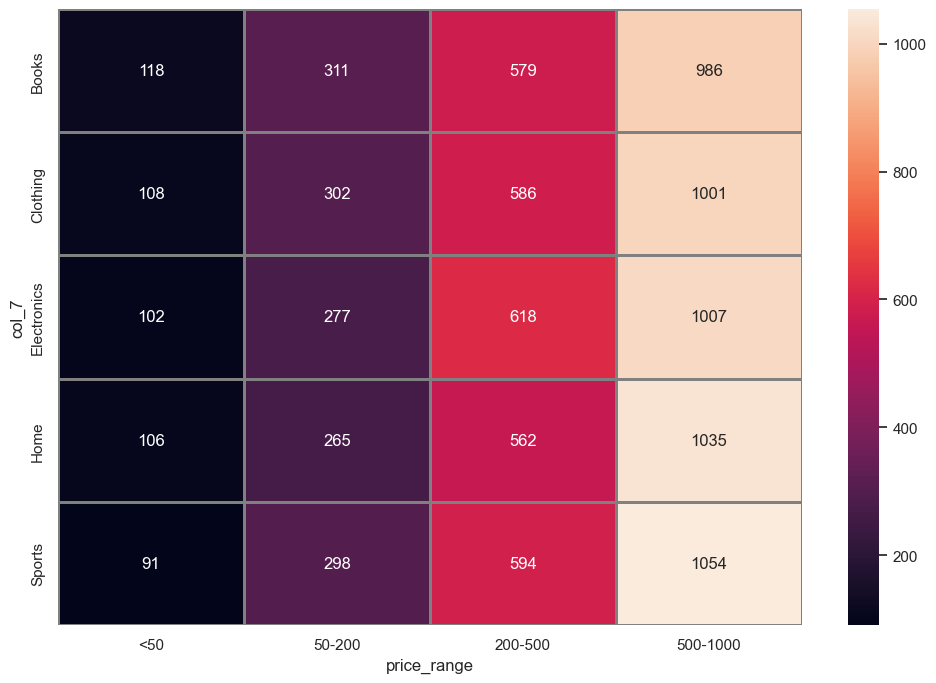

In [29]:
#41
bins = [0, 50, 200, 500, 1000, float('inf')]
labels = ['<50', '50-200', '200-500', '500-1000', '>1000']
df['price_range'] = pd.cut(df['col_2'], bins=bins, labels=labels, include_lowest=True)
heatmap_data = pd.crosstab(df['col_7'], df['price_range'])
plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, annot=True, fmt='d', linewidths=1)
plt.show()

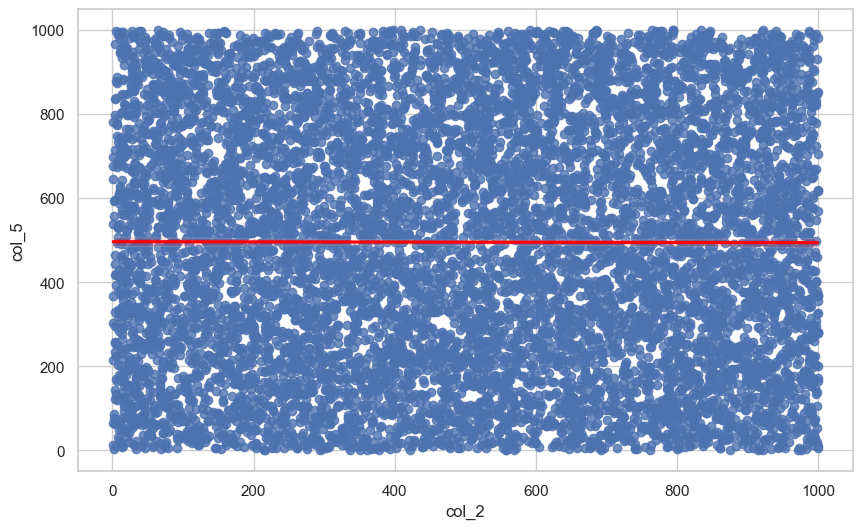

In [34]:
#42
plt.figure(figsize=(10, 6))
sns.regplot(data=df, x='col_2', y='col_5', line_kws={'color':'red'})
plt.show()

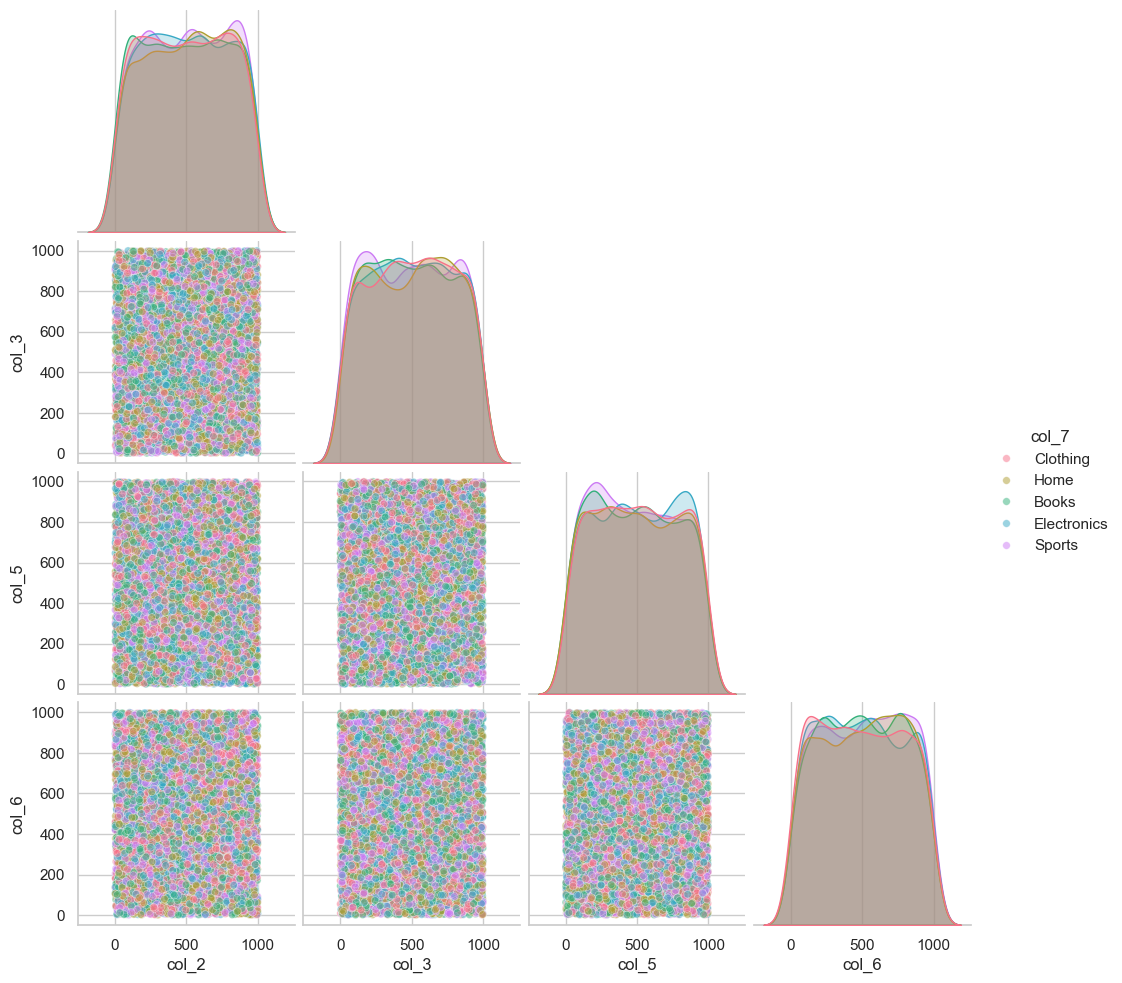

In [35]:
#43
l = ['col_2', 'col_3', 'col_4', 'col_5', 'col_6', 'col_7']
subset_df = df[l]
pair_grid = sns.pairplot(subset_df, hue='col_7', palette='husl', corner=True, diag_kind='kde', plot_kws={'alpha': 0.5, 's': 30})
plt.show()

In [36]:
#44
k2 = df['col_2'].mean() + 3 * df['col_2'].std()
k3 = df['col_3'].mean() + 3 * df['col_3'].std()
j = df[(df['col_2'] > k2) | (df['col_3'] > k3)]
print(j)

Empty DataFrame
Columns: [col_1, col_2, col_3, col_4, col_5, col_6, col_7, col_8, col_9, col_10, col_11, col_12, col_13, col_14, col_15, col_16, col_17, col_18, col_19, col_20, col_21, col_22, col_23, col_24, col_25, col_26, col_27, col_28, col_29, col_30, col_31, col_32, col_33, col_34, col_35, col_36, col_37, col_38, col_39, col_40, col_41, col_42, col_43, col_44, col_45, col_46, col_47, col_48, col_49, col_50, price_range]
Index: []

[0 rows x 51 columns]


In [39]:
#45
category_summary = df.groupby('col_7').agg({'col_2': 'mean', 'col_3': 'sum'}).reset_index()

top_10_stock = df.sort_values(by='col_3', ascending=False).head(10)

top_10_value = df.sort_values(by='total_value', ascending=False).head(10)

file_name = 'catalog_final_report.xlsx'
with pd.ExcelWriter(file_name, engine='openpyxl') as writer:
    category_summary.to_excel(writer, sheet_name='Свод по категориям', index=False)
    top_10_stock.to_excel(writer, sheet_name='Топ-10 запас', index=False)
    top_10_value.to_excel(writer, sheet_name='Топ-10 стоимость', index=False)
    df.to_excel(writer, sheet_name='Полный каталог', index=False)